# 1. Configuration & Imports

In [25]:
import comet_ml
import os
import sys
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import mplfinance as mpf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Conv1D, MaxPooling1D
from sklearn.utils.class_weight import compute_class_weight
import pandas_ta as ta

# --- Configuration Globale ---
COMET_API_KEY = str(input("Commet api key: ")) # Remplacer par votre clé


In [51]:
WINDOW_SIZE = 60 # Taille de la fenêtre temporelle pour le RNN
NORM_WINDOW = 200 # Taille de la fenêtre glissante pour la normalisation
# Frais d'échange
SELL_FEES = 0.001
BUY_FEES = 0.001

# 2. Récupération des données

In [2]:
# Optionnel : Mettre vos identifiants DB si vous voulez télécharger de nouvelles données
# DB_URL = "https://trader.derveloy.eu/"
# DB_PASSWORD = "votre_mot_de_passe"

data_file = "data/bitcoin_candles.csv"

if os.path.exists(data_file):
    print("Chargement des données depuis le fichier CSV local...")
    df_btc = pd.read_csv(data_file)
    df_btc["time"] = pd.to_datetime(df_btc["time"])
else:
    print("Fichier CSV introuvable. Veuillez exécuter le code de connexion à la DB.")
    # (Le code de la DB a été mis de côté pour ne pas bloquer l'exécution)
    
numeric_cols = ["open", "high", "low", "close", "volume"]
df_btc[numeric_cols] = df_btc[numeric_cols].astype(float)
df_btc = df_btc.sort_values("time").reset_index(drop=True)
print(f"Total candles loaded: {len(df_btc)}")


Chargement des données depuis le fichier CSV local...
Total candles loaded: 252311


# 3. Indicateurs Techniques & Normalisation Causale (Look-ahead bias free)

In [3]:
def add_features_and_normalize(df, n_window):
    df = df.copy()
    
    # 1. Calcul des indicateurs techniques de base (pandas-ta)
    # VWAP nécessite l'index datetime
    df.set_index('time', inplace=True)
    df['vwap'] = ta.vwap(df['high'], df['low'], df['close'], df['volume'])
    df.reset_index(inplace=True)
    
    df['rsi'] = ta.rsi(df['close'], length=14)
    df['atr'] = ta.atr(df['high'], df['low'], df['close'], length=14)
    df['obv'] = ta.obv(df['close'], df['volume'])
    
    # Remplir les premiers NaN créés par les indicateurs
    df = df.bfill()
    
    # 2. Normalisation purement causale (Rolling Window)
    # Prix & VWAP : (Prix / Moyenne Mobile)
    for col in ['open', 'high', 'low', 'close', 'vwap']:
        df[col + '_norm'] = df[col] / df[col].rolling(window=n_window, min_periods=1).mean()
        
    # Volume : (Volume / Moyenne Mobile Volume)
    df['volume_norm'] = df['volume'] / df['volume'].rolling(window=n_window, min_periods=1).mean()
    
    # RSI : Normalisation 0-1
    df['rsi_norm'] = df['rsi'] / 100.0
    
    # ATR : Volatilité en % du prix
    df['atr_norm'] = df['atr'] / df['close']
    
    # OBV : Détendance glissante
    df['obv_norm'] = df['obv'] / df['obv'].rolling(window=n_window, min_periods=1).mean()
    
    # MACD calculé sur le prix *déjà normalisé* pour garder une échelle constante
    macd = ta.macd(df['close_norm'], fast=12, slow=26, signal=9)
    # pandas-ta MACD retourne 3 colonnes: MACD_12_26_9, MACDh_12_26_9 (histogramme), MACDs_12_26_9 (signal)
    if macd is not None:
        df['macd_norm'] = macd.iloc[:, 0]
        df['macd_hist_norm'] = macd.iloc[:, 1]
    else:
        df['macd_norm'] = 0
        df['macd_hist_norm'] = 0
    
    # Remplacer les valeurs infinies ou NaN potentielles issues des divisions par 0
    df = df.replace([np.inf, -np.inf], np.nan).bfill().fillna(0)
    
    return df

print("Calcul des indicateurs et normalisation (fenêtre de", NORM_WINDOW, ")...")
df_featured = add_features_and_normalize(df_btc, NORM_WINDOW)
print("Normalisation terminée.")


Calcul des indicateurs et normalisation (fenêtre de 200 )...
Normalisation terminée.


# 4. Génération des Labels

In [125]:
def max_drawdown_tolerance(dt: pd.Timedelta) -> float:
    return 0.95 # Essayons en considérons que nous acceptions aucun dropdown ou presque. On sort dés qu'il y a une base.
    """
    Pourquoi : De cette façon j'espère forcer le bot a prendre des bénéfice dés qu'il peut. Je ne veux pas perdre +0.3% sur un guess de l'IA que ca va remonté après un chute.
    Je pense que c'est quelque chose de trop dure a deviner.
    """
    
    # max obtenue -36% rendement.
    # NE PAS SUPPRIMER LE CODE
    CROP_DURATION = 14400 # 4 heures
    dt = min(CROP_DURATION, dt.total_seconds())
    value = 0.5 + (3/4)*(dt/CROP_DURATION)
    return min(0.9, value)

def is_green(candles: pd.Series) -> bool:
    return candles["open"] < candles["close"]

def is_profitable_with_fees(buy: pd.Series, sell: pd.Series) -> tuple[bool, float]:
    capital_multiplier = (sell["close"] / buy["close"]) * (1 - BUY_FEES) * (1 - SELL_FEES)
    return (capital_multiplier > 1.0, capital_multiplier)

def generate_labels(dataframe: pd.DataFrame) -> pd.DataFrame:
    print("Génération des labels en cours...")
    index = 0
    positions = []
    END_INDEX = dataframe.shape[0] 
    
    while index < END_INDEX:
        if is_green(dataframe.iloc[index]): 
            start_candle = index
            max_price = max(dataframe.iloc[index]["close"], dataframe.iloc[index]["open"])
            
            while index < END_INDEX:
                last_candle = index
                index += 1
                if index >= END_INDEX:
                    break
                
                max_price = max(max_price, max(dataframe.iloc[index]["close"], dataframe.iloc[index]["open"]))
                
                if not is_green(dataframe.iloc[index]): 
                    time_diff = dataframe.iloc[last_candle]["time"] - dataframe.iloc[start_candle]["time"]
                    drawdown = (dataframe.iloc[index]["close"] - dataframe.iloc[start_candle]["open"])/(max_price-dataframe.iloc[start_candle]["open"]) if (max_price-dataframe.iloc[start_candle]["open"]) != 0 else 0
                    
                    if not (drawdown > max_drawdown_tolerance(time_diff)):
                        if (len(positions) > 0) and (dataframe.iloc[positions[-1][1]]["time"] - dataframe.iloc[start_candle]["time"] < pd.Timedelta(hours=1.5)) and (dataframe.iloc[positions[-1][1]]["close"] < dataframe.iloc[start_candle]["close"]):
                            positions[-1][1] = last_candle 
                            break
                        else:
                            if start_candle != last_candle:
                                positions.append([start_candle, last_candle])
                            break
        else:
            index += 1

    ret = dataframe.copy()
    ret["type"] = "hold"
    ret["capital_multiplier"] = float(1)

    for start_candle, last_candle in positions:
        is_profitable, capital_multiplier = is_profitable_with_fees(dataframe.iloc[start_candle], dataframe.iloc[last_candle])
        if is_profitable:
            ret.loc[dataframe.index[start_candle], "type"] = "buy"
            ret.loc[dataframe.index[last_candle], "type"] = "sell"
            ret.loc[dataframe.index[last_candle], "capital_multiplier"] = capital_multiplier

    print(f"Génération terminée. Nombres de trades trouvés : {len(positions)}")
    return ret

df_labeled = generate_labels(df_featured)


Génération des labels en cours...
Génération terminée. Nombres de trades trouvés : 26711


In [14]:
df_labeled.info()

<class 'pandas.DataFrame'>
RangeIndex: 252311 entries, 0 to 252310
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   time                252311 non-null  datetime64[us, UTC]
 1   symbol              252311 non-null  str                
 2   timeframe           252311 non-null  str                
 3   open                252311 non-null  float64            
 4   high                252311 non-null  float64            
 5   low                 252311 non-null  float64            
 6   close               252311 non-null  float64            
 7   volume              252311 non-null  float64            
 8   vwap                252311 non-null  float64            
 9   rsi                 252311 non-null  float64            
 10  atr                 252311 non-null  float64            
 11  obv                 252311 non-null  float64            
 12  open_norm           252311 

# 4.1 Visualisation de la stratégie de Labeling (Vérification)

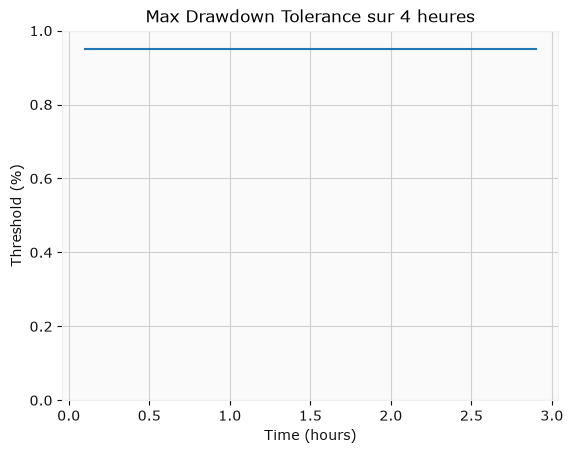

Global output (Multiplier):  1.8020815799961559e+47
Mean multiplier per trade:  1.000435573078002
Number of positions (sells):  17449


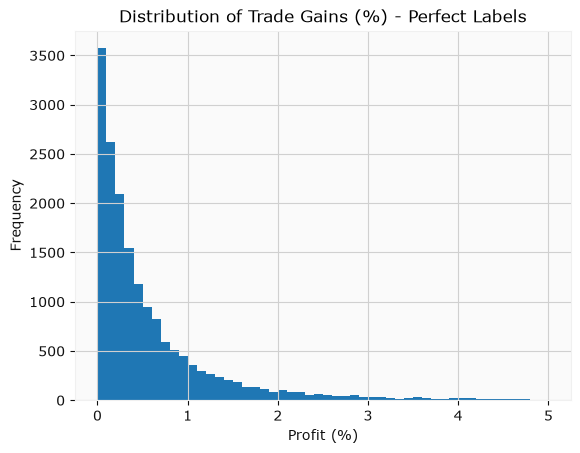

In [126]:
# --- 1. Visualisation du Drawdown Tolerance ---
fig, ax = plt.subplots()
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Threshold (%)")
ax.set_ylim(0, 1)
ax.plot(np.arange(0.1, 3.0, 0.1), [max_drawdown_tolerance(dt=pd.Timedelta(seconds=x*600)) for x in range(1, 30, 1)])
plt.title("Max Drawdown Tolerance sur 4 heures")
plt.show()

# --- 2. Statistiques des gains sur les données complètes ---
print("Global output (Multiplier): ", df_labeled["capital_multiplier"].prod())
print("Mean multiplier per trade: ", df_labeled["capital_multiplier"].mean())
print("Number of positions (sells): ", len(df_labeled[df_labeled["type"] == "sell"]))

# --- 3. Histogramme des pourcentages de gain ---
sells = df_labeled[df_labeled["type"] == "sell"].copy()
sells["profit_pct"] = (sells["capital_multiplier"] - 1) * 100

sells["profit_pct"].plot(
    kind="hist",
    bins=50,
    range=(0, 5),
    title="Distribution of Trade Gains (%) - Perfect Labels",
    xlabel="Profit (%)",
    grid=True
)
plt.show()


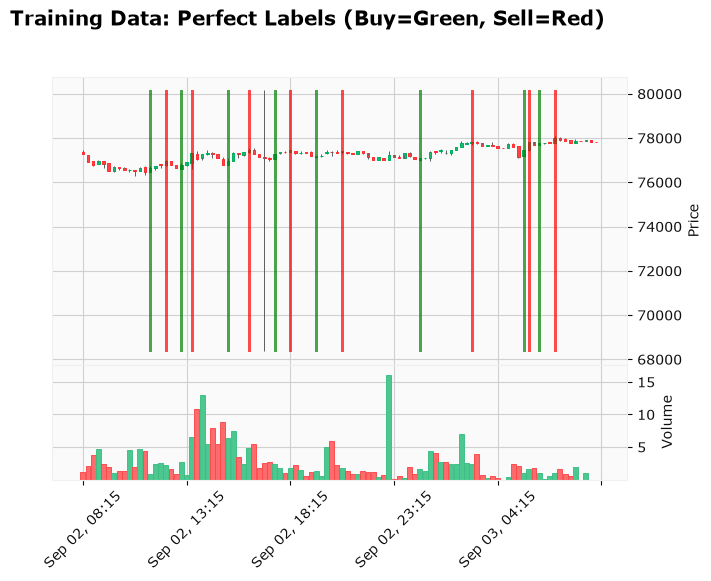

In [130]:
# --- 4. Affichage sur le graphique (200 bougies) ---
df_subset = df_labeled.tail(100).copy()

df_plot = df_subset.rename(columns={
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "volume": "Volume"
}).set_index("time")

buy_dates = df_plot[df_plot["type"] == "buy"].index.tolist()
sell_dates = df_plot[df_plot["type"] == "sell"].index.tolist()

vlines_dates = buy_dates + sell_dates
vlines_colors = ["g"] * len(buy_dates) + ["r"] * len(sell_dates)

if vlines_dates:
    vlines_kwargs = dict(vlines=vlines_dates, colors=vlines_colors, linewidths=1.0, alpha=0.7)
    mpf.plot(
        df_plot,
        type="candle",
        style="yahoo",
        volume=True,
        vlines=vlines_kwargs,
        title="Training Data: Perfect Labels (Buy=Green, Sell=Red)"
    )
else:
    print("No buy/sell signals in this range.")
    mpf.plot(
        df_plot,
        type="candle",
        style="yahoo",
        volume=True,
        title="Training Data: No signals"
    )


# 5. Préparation des Séquences (Train/Test Split)

In [131]:
# 1. Séparation Chronologique (Dernière année pour le test)
last_timestamp = df_labeled["time"].max()
div_timestamp = last_timestamp - pd.Timedelta(days=365)

train_data = df_labeled[df_labeled["time"] < div_timestamp].copy().reset_index(drop=True)
test_data = df_labeled[df_labeled["time"] >= div_timestamp].copy().reset_index(drop=True)

print(f"Train data: {train_data['time'].min()} to {train_data['time'].max()} ({len(train_data)} candles)")
print(f"Test data: {test_data['time'].min()} to {test_data['time'].max()} ({len(test_data)} candles)")

# 2. Sélection des features normalisées
features = [
    "open_norm", "high_norm", "low_norm", "close_norm", "volume_norm", 
    "vwap_norm", "rsi_norm", "atr_norm", "obv_norm", "macd_norm", "macd_hist_norm"
]

X_train_raw = train_data[features].values
X_test_raw = test_data[features].values

# 3. Target Encoding (One-hot encoding)
label_mapping = {"hold": 0, "buy": 1, "sell": 2}
y_train_encoded = tf.keras.utils.to_categorical(train_data["type"].map(label_mapping))
y_test_encoded = tf.keras.utils.to_categorical(test_data["type"].map(label_mapping))

# 4. Génération des fenêtres glissantes
def create_dataset(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

print("Création des séquences glissantes (cela peut prendre un moment)...")
X_train, y_train = create_dataset(X_train_raw, y_train_encoded, WINDOW_SIZE)
X_test, y_test = create_dataset(X_test_raw, y_test_encoded, WINDOW_SIZE)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")


Train data: 2018-12-15 03:00:00+00:00 to 2025-09-03 08:45:00+00:00 (219580 candles)
Test data: 2025-09-03 09:00:00+00:00 to 2026-09-03 09:00:00+00:00 (32731 candles)
Création des séquences glissantes (cela peut prendre un moment)...
X_train shape: (219520, 60, 11), y_train shape: (219520, 3)


# 5.5 Charger un modèle existant (Optionnel)

In [ ]:
import os
from tensorflow.keras.models import load_model

weights_dir = "models"
if not os.path.exists(weights_dir):
    os.makedirs(weights_dir)

print("Modèles disponibles dans le dossier 'weights' :")
fichiers = [f for f in os.listdir(weights_dir) if f.endswith(".keras") or f.endswith(".h5")]
if fichiers:
    for file in fichiers:
        print(f" - {file}")
else:
    print(" (Aucun modèle trouvé)")

filename = input("Quel fichier voulez-vous charger ? (Laissez vide pour ignorer et créer un nouveau modèle) : ")

if filename.strip():
    if not filename.endswith(".keras") and not filename.endswith(".h5"):
        filename += ".keras"
        
    filepath = os.path.join(weights_dir, filename)
    if os.path.exists(filepath):
        model = load_model(filepath)
        print(f"\n✅ Modèle '{filename}' chargé avec succès !")
        print("\n⚠️ ATTENTION : Ignorez la cellule 6 (Création du modèle) si vous avez chargé un modèle, sinon il sera écrasé.")
    else:
        print(f"\n❌ Erreur : Le fichier '{filepath}' n'existe pas.")
else:
    print("\nAucun modèle chargé. Exécutez la cellule suivante pour créer un nouveau modèle.")


# 6. Modèle Deep Learning (CNN + GRU)

In [132]:
LEARNING_RATE = 0.001

# Calcul des poids de classe pour compenser le déséquilibre
y_train_labels = np.argmax(y_train, axis=1)
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_labels), y=y_train_labels)
class_weight_dict = {i: weight for i, weight in enumerate(weights)}
print(f"Poids appliqués : {class_weight_dict}")

model = Sequential([
    Input(shape=(WINDOW_SIZE, len(features))),
    
    # Partie Convolutionnelle (Feature Extraction de motifs locaux)
    Conv1D(filters=32, kernel_size=10, activation='relu', padding='same'), # avant : kernel_size = 3
    MaxPooling1D(pool_size=2), # Réduit la séquence temporelle de 60 à 30
    
    # Partie Récurrente
    GRU(units=16, return_sequences=True),
    Dropout(0.3),
    GRU(units=16, return_sequences=False),
    Dropout(0.3),
    
    # Couches de décision
    Dense(units=8, activation='relu'),
    Dense(units=3, activation='softmax') # 3 classes: hold, buy, sell
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.categorical_crossentropy,
    metrics=['accuracy']
)

model.summary()


Poids appliqués : {0: np.float64(0.38828631870891966), 1: np.float64(4.710527445174026), 2: np.float64(4.710527445174026)}


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 60, 32)         │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_14 (GRU)                    │ (None, 30, 16)         │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_15 (GRU)                    │ (None, 16)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,283 (20.64 KB)

 Trainable params: 5,283 (20.64 KB)

 Non-trainable params: 0 (0.00 B)

# 7.1 Initialisation de Comet ML (À lancer UNE SEULE FOIS)

In [134]:
experiment.end() # On vérifie que l'ancienne expérience est bien terminé.
# Initialisation de Comet ML (Crée une seule expérience continue)
experiment = comet_ml.Experiment(
    api_key=COMET_API_KEY,
    project_name="trader-ai"
)
BATCH_SIZE = 512

experiment.log_parameters({
    "batch_size": BATCH_SIZE,
    "window_size": WINDOW_SIZE,
    "norm_window": NORM_WINDOW
})

comet_callback = experiment.get_callback('keras')

epochs_deja_faits = 0  # Compteur global
global_history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: keras, sklearn, tensorflow.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/louisderveloy/trader-ai/363b966a6a304c5484f3715fd4da40d2



In [143]:
# Vous pouvez modifier ce nombre avant chaque relance
EPOCHS = 15

print(f"Reprise de l'entraînement : de l'epoch {epochs_deja_faits + 1} à {epochs_deja_faits + EPOCHS}")

history = model.fit(
    X_train, y_train,
    initial_epoch=epochs_deja_faits,               # Reprend au bon endroit
    epochs=epochs_deja_faits + EPOCHS,     # S'arrête au bon endroit
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    shuffle=False,
    class_weight=class_weight_dict,
    callbacks=[comet_callback]
)

epochs_deja_faits += EPOCHS

# Ajout à l'historique global pour l'affichage complet
for key in global_history.keys():
    global_history[key].extend(history.history.get(key, []))


Reprise de l'entraînement : de l'epoch 31 à 45
Epoch 31/45
343/343 ━━━━━━━━━━━━━━━━━━━━ 35s 103ms/step - accuracy: 0.1987 - loss: 0.8040 - val_accuracy: 0.1825 - val_loss: 1.0054
Epoch 32/45
343/343 ━━━━━━━━━━━━━━━━━━━━ 40s 115ms/step - accuracy: 0.1982 - loss: 0.8030 - val_accuracy: 0.1834 - val_loss: 1.0045
Epoch 33/45
343/343 ━━━━━━━━━━━━━━━━━━━━ 42s 122ms/step - accuracy: 0.1946 - loss: 0.8028 - val_accuracy: 0.1765 - val_loss: 1.0081
Epoch 34/45
343/343 ━━━━━━━━━━━━━━━━━━━━ 44s 128ms/step - accuracy: 0.1969 - loss: 0.8023 - val_accuracy: 0.1737 - val_loss: 1.0123
Epoch 35/45
343/343 ━━━━━━━━━━━━━━━━━━━━ 42s 124ms/step - accuracy: 0.1965 - loss: 0.8026 - val_accuracy: 0.1760 - val_loss: 1.0081
Epoch 36/45
343/343 ━━━━━━━━━━━━━━━━━━━━ 43s 124ms/step - accuracy: 0.1955 - loss: 0.8013 - val_accuracy: 0.1625 - val_loss: 1.0104
Epoch 37/45
343/343 ━━━━━━━━━━━━━━━━━━━━ 43s 125ms/step - accuracy: 0.1911 - loss: 0.8008 - val_accuracy: 0.1709 - val_loss: 1.0003
Epoch 38/45
343/343 ━━━━━━━━━

In [146]:
experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : administrative_glazing_2791
COMET INFO:     url                   : https://www.comet.com/louisderveloy/trader-ai/363b966a6a304c5484f3715fd4da40d2
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [45]                 : (0.19106459617614746, 0.285902202129364)
COMET INFO:     batch_accuracy [1575]         : (0.14006200432777405, 0.646198570728302)
COMET INFO:     batch_loss [1575]             : (0.7467601299285889, 1.2630527019500732)
COMET INFO:     epoch_duration [45]           : (35.41372659994522, 48.112912699987646)
COMET INFO:     loss [45]                     : (0.7973887920379639, 1.1129766702651978)
COMET INFO:     val_accur

# 7.4 Sauvegarder le modèle

In [136]:
weights_dir = "models"
if not os.path.exists(weights_dir):
    os.makedirs(weights_dir)

filename = input("Entrez le nom pour sauvegarder le modèle (sans l'extension .keras), ou laissez vide pour annuler : ")

if filename.strip():
    filepath = os.path.join(weights_dir, f"{filename}.keras")
    model.save(filepath)
    print(f"✅ Modèle sauvegardé avec succès dans : {filepath}")
else:
    print("Sauvegarde annulée.")


✅ Modèle sauvegardé avec succès dans : models\no_dropdown_temp_30_epochs.keras


# 8. Évaluation et Simulation sur Données de Test

## 8.1 Test sur données

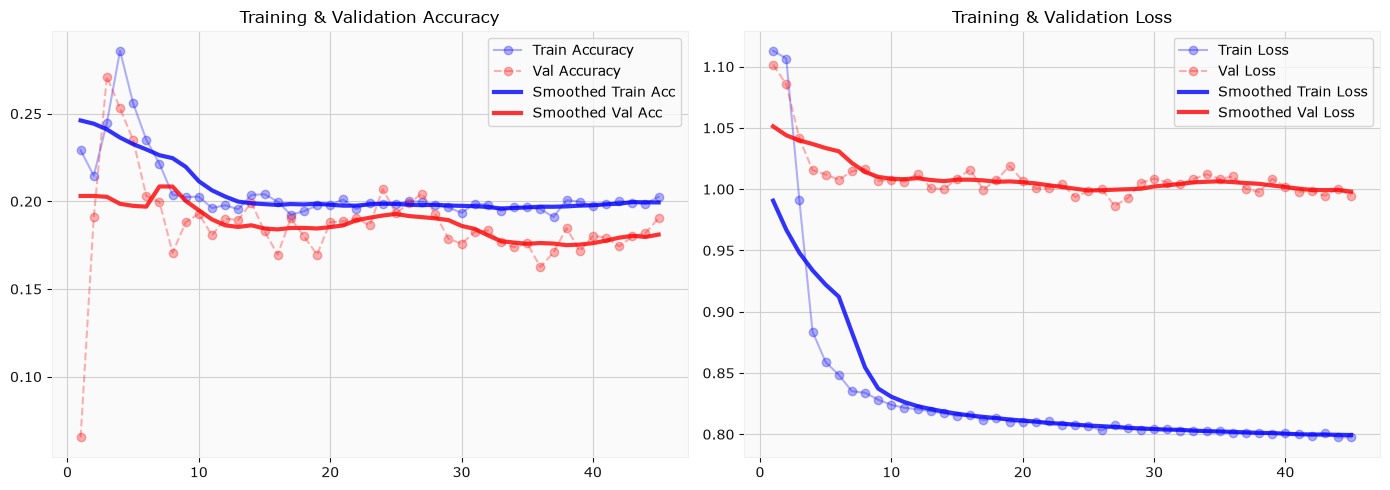

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Courbes d'entraînement ---
acc = global_history.get('accuracy', [])
val_acc = global_history.get('val_accuracy', [])
loss = global_history.get('loss', [])
val_loss = global_history.get('val_loss', [])
epochs_range = range(1, len(loss) + 1)
x = np.array(epochs_range)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Fonction pour lisser la courbe (Moyenne mobile centrée sur 5 valeurs)
def smooth(y_values, window=10):
    return pd.Series(y_values).rolling(window=window, center=True, min_periods=1).mean().values

# --- 1. Graphique Accuracy ---
ax1.plot(x, acc, 'b-o', label='Train Accuracy', alpha=0.3)
ax1.plot(x, val_acc, 'r--o', label='Val Accuracy', alpha=0.3)

if len(x) > 1:
    ax1.plot(x, smooth(acc), 'b-', alpha=0.8, linewidth=3, label='Smoothed Train Acc')
    ax1.plot(x, smooth(val_acc), 'r-', alpha=0.8, linewidth=3, label='Smoothed Val Acc')

ax1.set_title('Training & Validation Accuracy')
ax1.legend()
ax1.grid(True)

# --- 2. Graphique Loss ---
ax2.plot(x, loss, 'b-o', label='Train Loss', alpha=0.3)
ax2.plot(x, val_loss, 'r--o', label='Val Loss', alpha=0.3)

if len(x) > 1:
    ax2.plot(x, smooth(loss), 'b-', alpha=0.8, linewidth=3, label='Smoothed Train Loss')
    ax2.plot(x, smooth(val_loss), 'r-', alpha=0.8, linewidth=3, label='Smoothed Val Loss')

ax2.set_title('Training & Validation Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


## 8.2 Visualisation des pourcentages buy/sell/hold

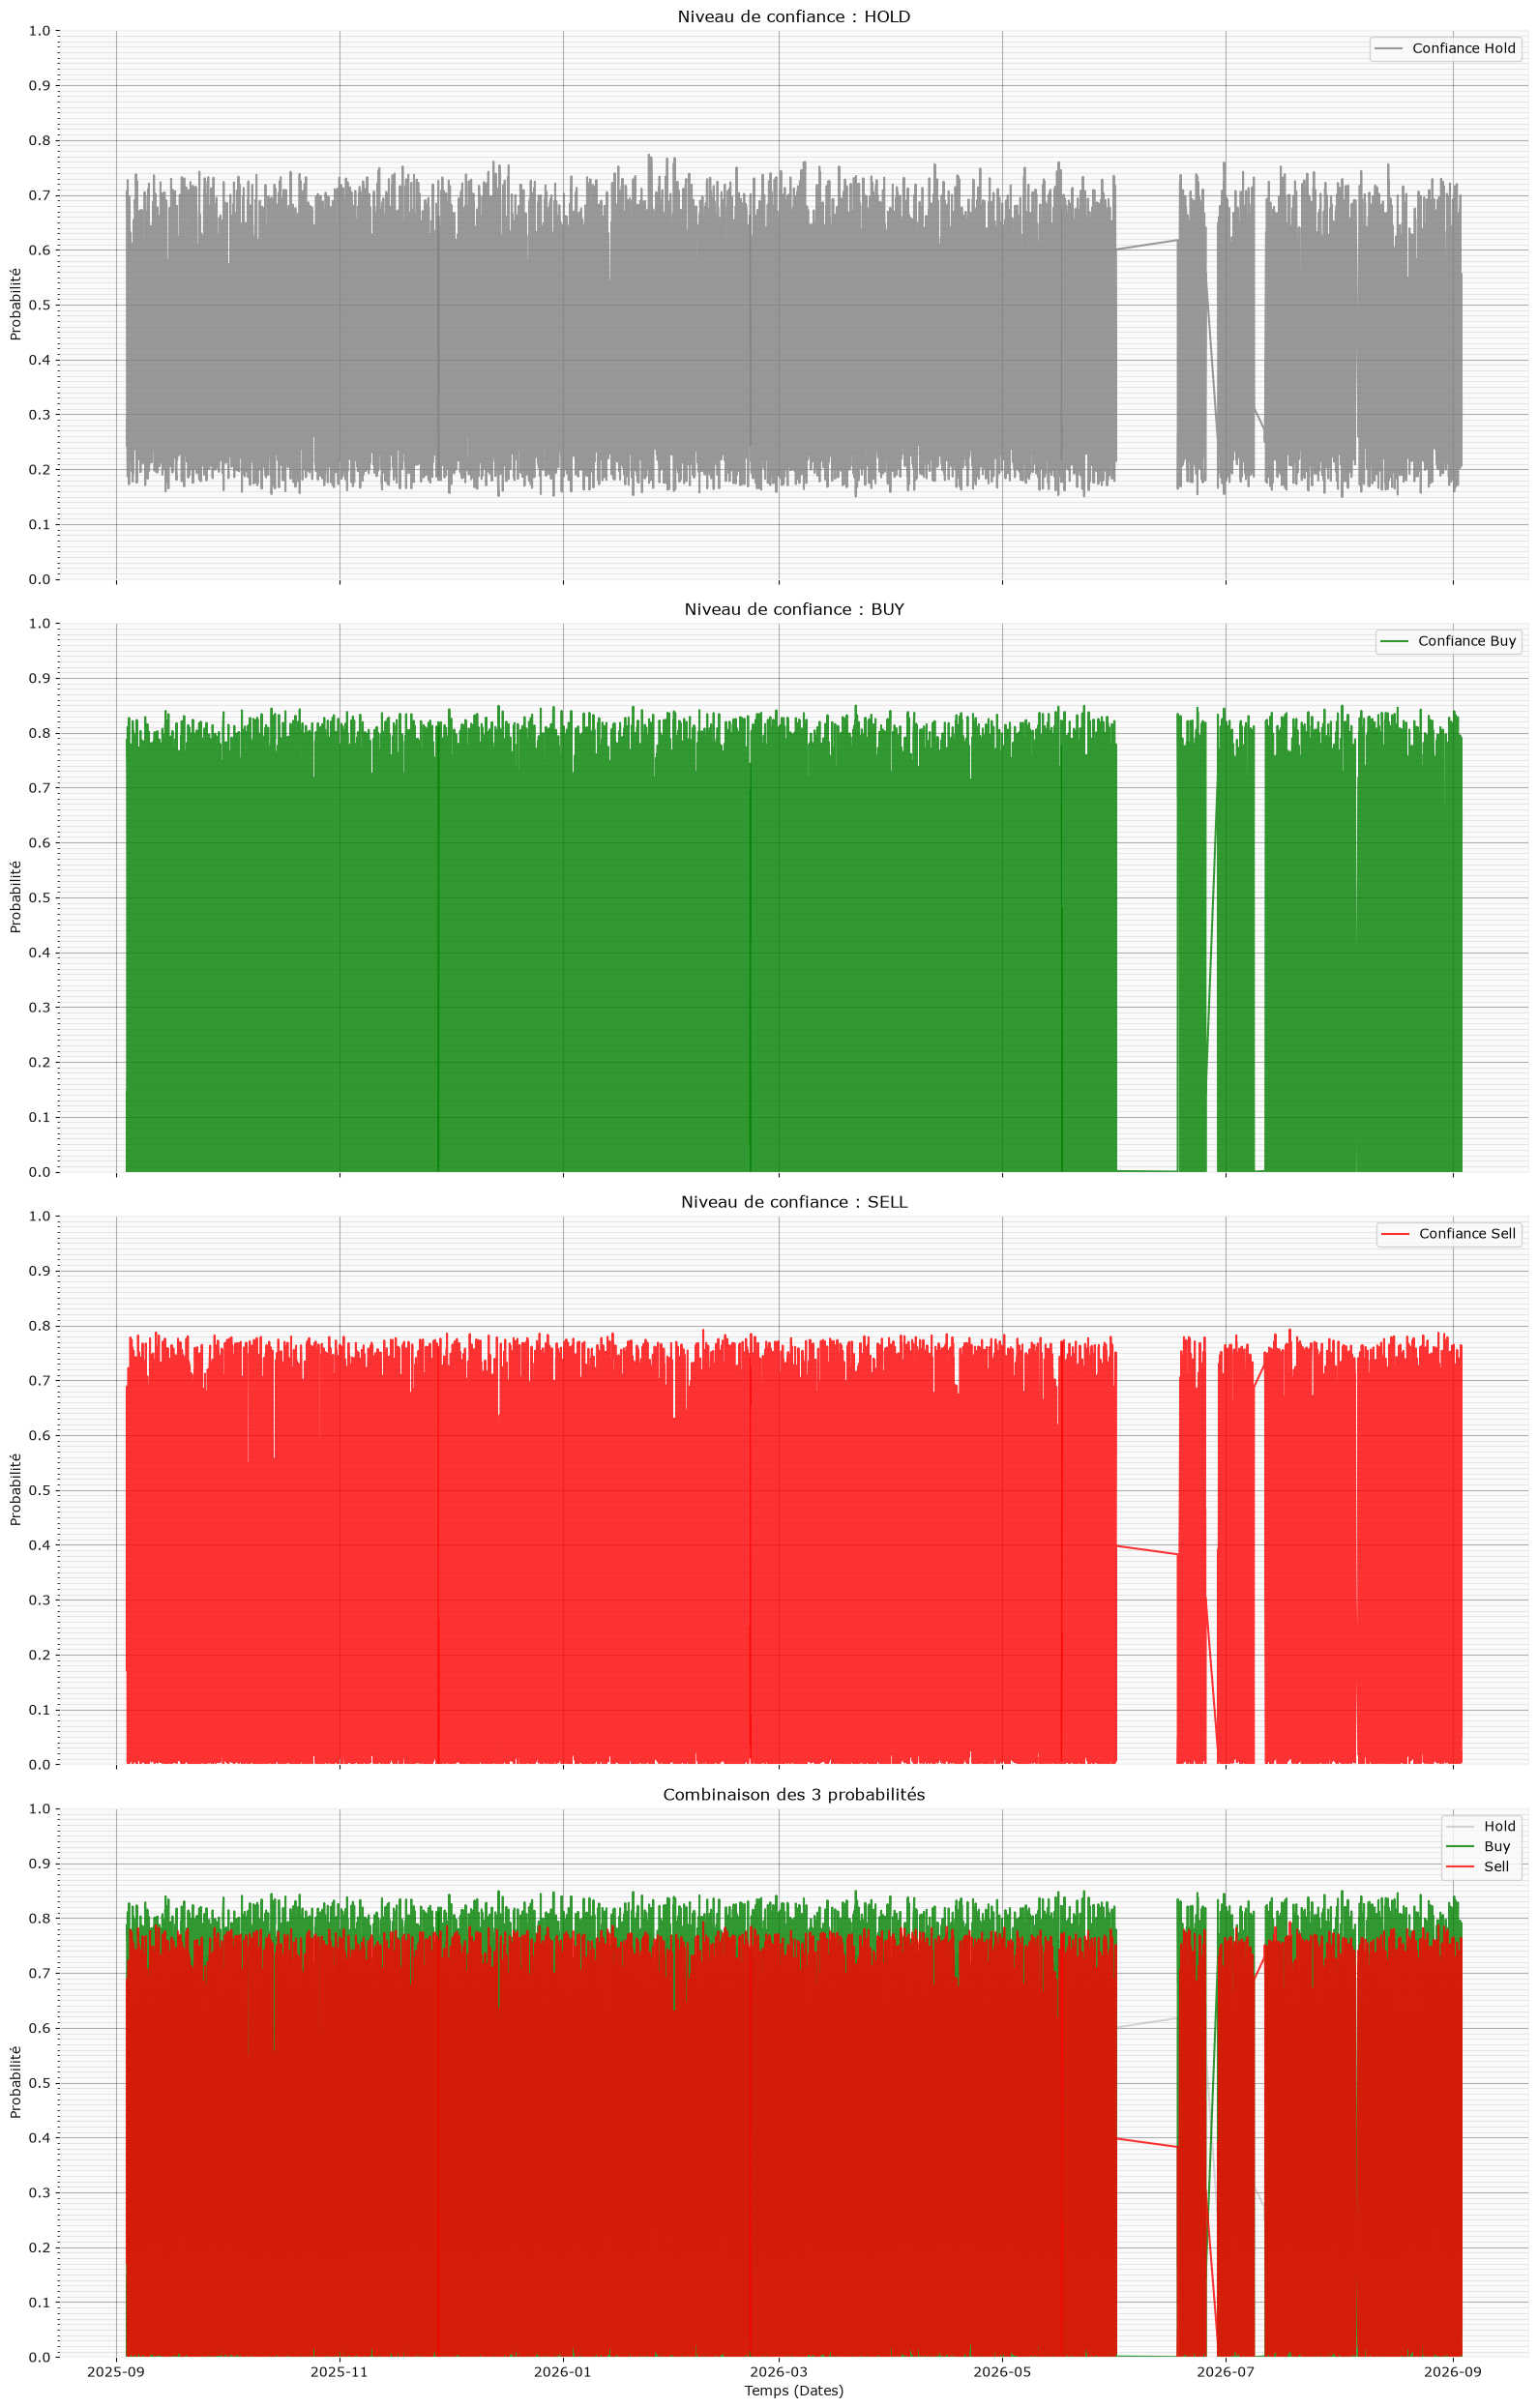

In [138]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Extraction des probabilités brutes (0 à 1) du modèle
prob_hold = predictions[:, 0]
prob_buy = predictions[:, 1]
prob_sell = predictions[:, 2]

# Récupération de l'axe temporel
df_temp = test_data.iloc[WINDOW_SIZE:]
if "time" in df_temp.columns:
    dates = df_temp["time"]
else:
    dates = df_temp.index

# Création d'une figure (hauteur augmentée pour lisibilité)
fig, axes = plt.subplots(4, 1, figsize=(16, 25), sharex=True)

axes[0].plot(dates, prob_hold, label="Confiance Hold", color="gray", alpha=0.8)
axes[0].set_title("Niveau de confiance : HOLD")

axes[1].plot(dates, prob_buy, label="Confiance Buy", color="green", alpha=0.8)
axes[1].set_title("Niveau de confiance : BUY")

axes[2].plot(dates, prob_sell, label="Confiance Sell", color="red", alpha=0.8)
axes[2].set_title("Niveau de confiance : SELL")

axes[3].plot(dates, prob_hold, label="Hold", color="gray", alpha=0.3)
axes[3].plot(dates, prob_buy, label="Buy", color="green", alpha=0.8)
axes[3].plot(dates, prob_sell, label="Sell", color="red", alpha=0.8)
axes[3].set_title("Combinaison des 3 probabilités")

for ax in axes:
    ax.set_ylim(0, 1)
    ax.set_ylabel("Probabilité")
    ax.legend(loc="upper right")
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.01))
    ax.grid(which='major', color='black', alpha=0.3, linewidth=0.8)
    ax.grid(which='minor', color='gray', alpha=0.3, linewidth=0.4)

plt.xlabel("Temps (Dates)")
plt.tight_layout()
plt.show()


## 8.3 Evaluation du rendement et visualization buy/sell sur graphique


--- Trading Simulation Results (Strict Alternation) ---
Total Trades Executed: 74
Global Capital Multiplier: 0.6352 (-36.48%)
-----------------------------------------------------



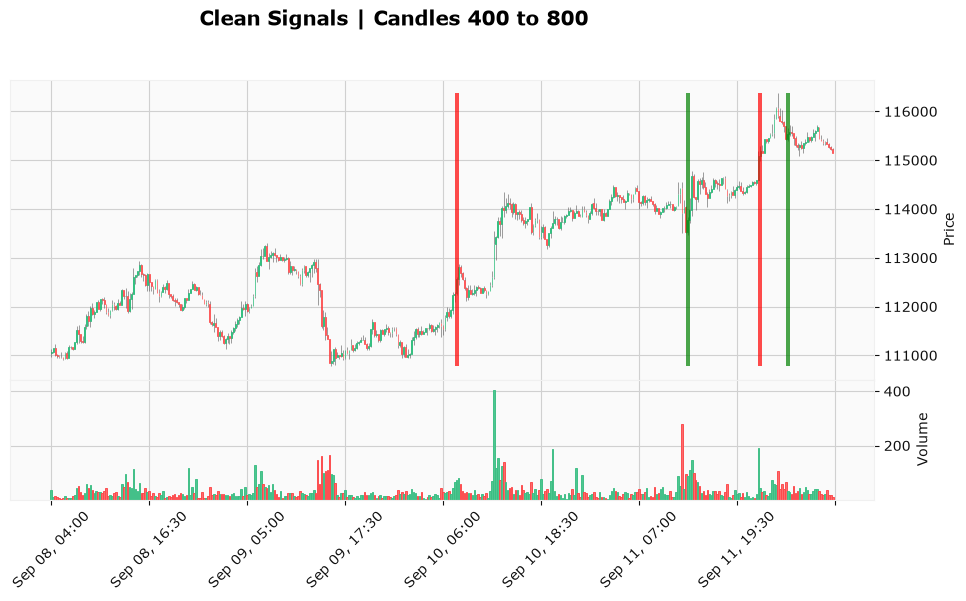

In [145]:
# --- DÉFINITION DES LIMITES (Modifiables sans recalculer les graphiques) ---
BUY_THRESHOLD = 0.795
SELL_THRESHOLD = 0.775

# 1. Application des limites sur les prédictions existantes
predicted_classes = []
for prob in predictions:
    if prob[1] > BUY_THRESHOLD: predicted_classes.append(1)
    elif prob[2] > SELL_THRESHOLD: predicted_classes.append(2)
    else: predicted_classes.append(0)

reverse_mapping = {0: "hold", 1: "buy", 2: "sell"}
predicted_labels = [reverse_mapping[c] for c in predicted_classes]

# 2. Alignement avec les données de test
df_results = test_data.iloc[WINDOW_SIZE:].copy()
df_results["predicted_signal"] = predicted_labels

# 3. Filtrage Alternance Stricte (Buy -> Sell -> Buy -> Sell)
filtered_signals = []
current_state = 'none' 

for sig in df_results['predicted_signal']:
    if sig == 'buy' and current_state in ['none', 'sold']:
        filtered_signals.append('buy')
        current_state = 'bought'
    elif sig == 'sell' and current_state == 'bought':
        filtered_signals.append('sell')
        current_state = 'sold'
    else:
        filtered_signals.append('hold')

df_plot_interactive = df_results.copy()
df_plot_interactive['clean_signal'] = filtered_signals

# 4. Calcul de la rentabilité globale
global_multiplier = 1.0
trades_count = 0
last_buy_row = None

for idx, row in df_plot_interactive.iterrows():
    if row['clean_signal'] == 'buy':
        last_buy_row = row
    elif row['clean_signal'] == 'sell' and last_buy_row is not None:
        is_prof, multiplier = is_profitable_with_fees(last_buy_row, row)
        global_multiplier *= multiplier
        trades_count += 1
        last_buy_row = None

print(f"\n--- Trading Simulation Results (Strict Alternation) ---")
print(f"Total Trades Executed: {trades_count}")
print(f"Global Capital Multiplier: {global_multiplier:.4f} ({(global_multiplier - 1)*100:.2f}%)")
print(f"-----------------------------------------------------\n")

# 5. Visualisation mplfinance
START_INDEX = 400
CANDLES_PER_VIEW = 400

df_plot_interactive = df_plot_interactive.rename(columns={
    "open": "Open", "high": "High", "low": "Low", "close": "Close", "volume": "Volume"
})
if "time" in df_plot_interactive.columns:
    df_plot_interactive.set_index("time", inplace=True)

total_candles = len(df_plot_interactive)
end_idx = min(START_INDEX + CANDLES_PER_VIEW, total_candles)
df_slice = df_plot_interactive.iloc[START_INDEX:end_idx]

buys_in_slice = df_slice[df_slice["clean_signal"] == "buy"].index.tolist()
sells_in_slice = df_slice[df_slice["clean_signal"] == "sell"].index.tolist()

vlines_dates = buys_in_slice + sells_in_slice
vlines_colors = ["g"] * len(buys_in_slice) + ["r"] * len(sells_in_slice)
vlines_kwargs = dict(vlines=vlines_dates, colors=vlines_colors, linewidths=1.5, alpha=0.7) if vlines_dates else None

mpf.plot(
    df_slice,
    type="candle",
    style="yahoo",
    volume=True,
    vlines=vlines_kwargs,
    title=f"Clean Signals | Candles {START_INDEX} to {end_idx}",
    figsize=(12, 6)
)
